In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!pip install torchvision

In [3]:
import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")


Pytorch version: 2.11.0+cpu
torchvision version:0.26.0+cpu


In [4]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 265kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.2MB/s]


In [5]:
image, label = train_data[0]
print(f"image dim: {image.ndim}")
print(f"label: {label}")

image dim: 3
label: 9


In [6]:
image.shape

torch.Size([1, 28, 28])

In [7]:
# colour, height and width

In [8]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [9]:
class_names = train_data.classes

In [10]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

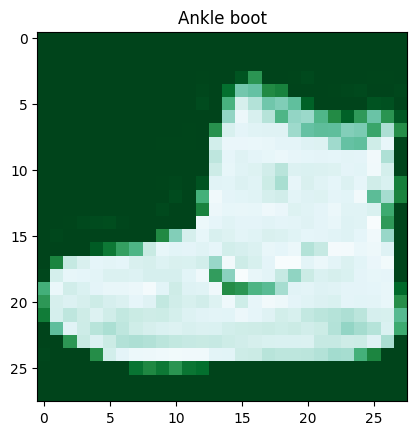

In [11]:
plt.imshow(image.squeeze(),cmap='BuGn_r')
plt.title(class_names[label])
plt.show()

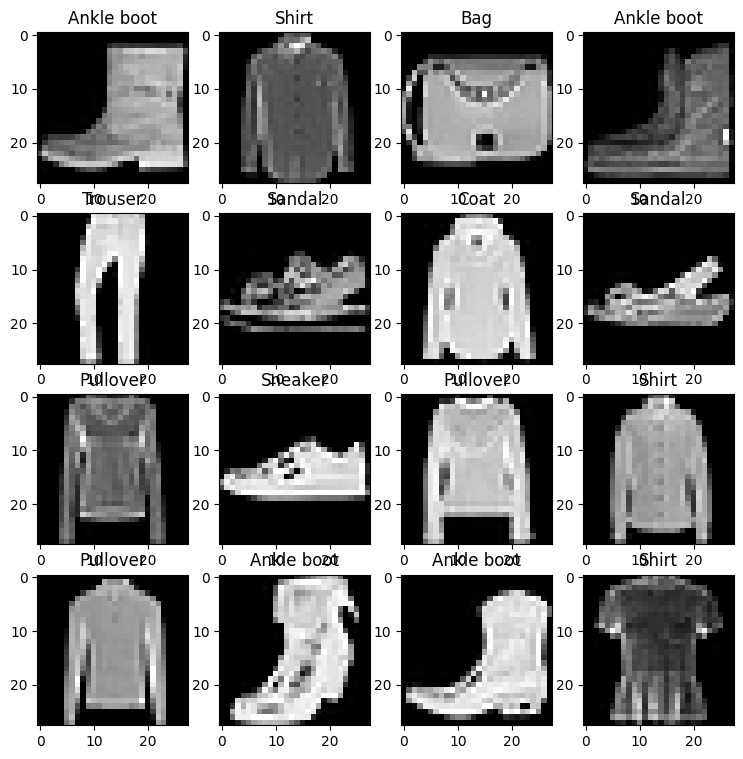

In [12]:
torch.manual_seed(42)

figure = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  image, label = train_data[random_idx]
  figure.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_names[label])


In [46]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

print(f"DataLoaders: {train_dataloader,test_dataloader}")
print(f"length of train_dataloader: {len(train_dataloader)} batches of : {BATCH_SIZE}")
print(f"length of test_dataloader: {len(test_dataloader)} batches of : {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7cd8bc345ac0>, <torch.utils.data.dataloader.DataLoader object at 0x7cd8bcf79340>)
length of train_dataloader: 1875 batches of : 32
length of test_dataloader: 313 batches of : 32


In [14]:
train_features_batch, train_features_label = next(iter(train_dataloader))
test_features_batch, test_features_label = next(iter(test_dataloader))
print(train_features_batch.shape, train_features_label.shape)

torch.Size([32, 1, 28, 28]) torch.Size([32])


In [15]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [colour_channels,height,width]")
print(f"Shape after flattening: {output.shape} -> [colour_channels,height*width]")

print(x)
print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [colour_channels,height,width]
Shape after flattening: torch.Size([1, 784]) -> [colour_channels,height*width]
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0

In [16]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape))

  def forward(self,x):
    return self.layer_stack(x)


model_0 = FashionMNISTModelV0(input_shape = 784,output_shape=len(class_names),hidden_units = 10)
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0282, -0.0165, -0.0101,  ..., -0.0272,  0.0052,  0.0173],
                      [ 0.0309, -0.0218, -0.0176,  ...,  0.0272, -0.0169,  0.0213],
                      [ 0.0087, -0.0238,  0.0124,  ..., -0.0115, -0.0096,  0.0006],
                      ...,
                      [-0.0131,  0.0312,  0.0269,  ..., -0.0275,  0.0082,  0.0330],
                      [ 0.0051,  0.0048, -0.0134,  ..., -0.0047, -0.0345,  0.0140],
                      [ 0.0278,  0.0035, -0.0279,  ...,  0.0152, -0.0084,  0.0227]])),
             ('layer_stack.1.bias',
              tensor([-0.0054, -0.0284, -0.0354, -0.0013,  0.0105, -0.0211,  0.0281,  0.0169,
                       0.0215,  0.0165])),
             ('layer_stack.2.weight',
              tensor([[-0.3050, -0.0580,  0.1643,  0.1565, -0.2877, -0.1792,  0.2305, -0.2618,
                        0.2397, -0.0610],
                      [ 0.0232,  0.1542,  0.0851, -0.2027,  0.1030, -0.2715, -0.

In [17]:
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [18]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [19]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr=0.1)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [21]:
from tqdm.auto import tqdm

torch.random.manual_seed(42)

epochs = 4

for epoch in tqdm(range(epochs)):
  train_loss = 0

  for batch, (X,y) in enumerate(train_dataloader):

    X.to(device), y.to(device)

    model_0.train()

    train_pred = model_0(X)
    loss = loss_fn(train_pred,y)
    train_loss += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # one full iteration through the samples

  train_loss/=len(train_dataloader)

  model_0.eval()
  test_loss,test_acc = 0,0
  with torch.inference_mode():
        for X,y in test_dataloader:
          X.to(device), y.to(device)
          test_pred = model_0(X)
          test_loss += loss_fn(test_pred,y)
          test_acc += accuracy_fn(y_true = y,
                                  y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
  print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")


  0%|          | 0/4 [00:00<?, ?it/s]


Train loss: 0.59176 | Test loss: 0.50948, Test acc: 82.21%


Train loss: 0.47375 | Test loss: 0.52864, Test acc: 81.62%


Train loss: 0.45340 | Test loss: 0.51284, Test acc: 82.81%


Train loss: 0.44325 | Test loss: 0.47325, Test acc: 83.26%



In [22]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):


    model.eval()
    with torch.inference_mode():
      eval_loss, eval_acc = 0, 0
      for X,y in data_loader:
          X.to(device), y.to(device)
          pred = model(X)

          # error between predicted probabilties and actual labels
          eval_loss += loss_fn(pred,y)
          # how much do predicted labels match the actual ones
          eval_acc += accuracy_fn(y_true= y,
                            y_pred=pred.argmax(dim=1))

      eval_loss /= len(data_loader)
      eval_acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": eval_loss.item(),
            "model_acc": eval_acc}

In [23]:
model_0_results = eval_model(model=model_0,
           data_loader = test_dataloader,
           loss_fn = loss_fn,
           accuracy_fn= accuracy_fn)

In [24]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4737595021724701,
 'model_acc': 83.23682108626198}

In [65]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
      super().__init__()
      self.layer_stack = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=input_shape,out_features=hidden_units),
          nn.ReLU(),
          nn.Linear(in_features=hidden_units,out_features=output_shape)
      )

    def forward(self, x):
      return self.layer_stack(x)

In [66]:
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape = len(class_names)).to(device)


In [67]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

In [60]:
def train_step(dataloader:torch.utils.data.DataLoader,
               model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss = 0
  train_acc = 0
  model.to(device)
  for batch, (X,y) in enumerate(dataloader):
    X.to(device), y.to(device)
    train_pred = model(X)
    loss = loss_fn(train_pred,y)
    acc = accuracy_fn(y_true=y,
                      y_pred=train_pred.argmax(dim=1))
    train_acc += acc
    train_loss += loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  # one full iteration through the samples
  train_acc/=len(dataloader)
  train_loss/=len(dataloader)

  print(f"\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(dataloader:torch.utils.data.DataLoader,
               model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  test_loss = 0
  test_acc = 0

  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X,y in dataloader:
      # print(len(dataloader),'||',y.shape,'||',X.shape)
      X.to(device), y.to(device)
      # 16 , 16,1,28,28

      test_pred = model(X)
      # print(test_pred.shape)
      loss = loss_fn(test_pred,y)
      acc = accuracy_fn(y_true=y,
                        y_pred=test_pred.argmax(dim=1))
      test_acc += acc
      test_loss += loss

  # one full iteration through the samples
    test_acc/=len(dataloader)
    test_loss/=len(dataloader)

    print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.5f}")


In [68]:
from tqdm.auto import tqdm
torch.manual_seed(42)

epochs = 4

for epoch in tqdm(range(epochs)):

   print(f"Epoch: {epoch}\n---------")
   train_step(dataloader = train_dataloader,
               model = model_1,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)

   test_step(dataloader = test_dataloader,
               model= model_1,
               loss_fn= loss_fn,
               accuracy_fn = accuracy_fn,
               device = device)
# Last layer ReLU= bad idea, turns everything into guesswork since every output only contains positive numbers.

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train loss: 1.04246 | Train accuracy: 65.06%

Test loss: 0.70857 | Test accuracy: 74.55072
Epoch: 1
---------

Train loss: 0.62831 | Train accuracy: 77.82%

Test loss: 0.59462 | Test accuracy: 78.87380
Epoch: 2
---------

Train loss: 0.54899 | Train accuracy: 81.08%

Test loss: 0.54679 | Test accuracy: 80.80072
Epoch: 3
---------

Train loss: 0.50919 | Train accuracy: 82.50%

Test loss: 0.51821 | Test accuracy: 82.01877


In [70]:
model_1_results = eval_model(model = model_1,
          data_loader = test_dataloader,
          loss_fn=loss_fn,
          accuracy_fn=accuracy_fn)

In [71]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5182077288627625,
 'model_acc': 82.01876996805112}

In [72]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_channels:int, hidden_channels:int, output_shape: int):
    """Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/"""
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        # 28 x 28 -> 14x14
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        # 14 x 14 -> 7x7
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # colour channels x flattened image (7*7)
        nn.Linear(in_features=hidden_channels*7*7,out_features=output_shape)
    )

  def forward(self,x) -> torch.Tensor:
    return self.classifier(self.block_2(self.block_1(x)))

In [74]:
torch.manual_seed(42)
# we are using a grayscale image
model_3 = FashionMNISTModelV2(input_channels=1,hidden_channels=10,output_shape=len(class_names))
model_3.to(device)

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [76]:
torch.manual_seed(42)

random_images = torch.randn(size=(32,3,64,64))
test_image = random_images[0]
print(f"Image batch shape: {random_images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [83]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding='same')

conv_layer(test_image)

tensor([[[ 1.3047,  1.4238,  0.9435,  ...,  0.3078,  0.4244, -0.3909],
         [ 0.6132,  1.5396,  0.0516,  ...,  0.8711,  0.4256, -0.3416],
         [ 1.0524,  0.3662,  1.0114,  ...,  0.2809, -0.2741,  0.3787],
         ...,
         [ 0.0377,  0.2981, -0.2432,  ..., -0.7283, -0.5767, -0.0783],
         [-0.2693, -0.0386, -0.0781,  ...,  0.4228, -0.1802, -0.5140],
         [ 0.5006, -0.5684,  0.1166,  ...,  0.5425, -0.3335,  0.7756]],

        [[-0.1153,  0.5129, -0.7227,  ..., -0.6758,  0.4840, -0.8125],
         [ 0.2266, -0.2840, -0.0319,  ...,  1.5599, -1.2449, -0.4410],
         [-0.6666,  0.2753, -0.1262,  ...,  0.1999, -0.8856, -0.4292],
         ...,
         [-0.0647, -0.1984, -0.6386,  ..., -0.0585, -0.7833, -0.0764],
         [ 0.2940, -0.6306, -0.2052,  ...,  0.2456, -0.7134,  0.7373],
         [-0.1683, -0.8397,  0.2643,  ...,  0.2593, -0.5630,  0.1587]],

        [[ 0.4864, -0.7476, -0.6414,  ...,  0.5477, -1.2156,  0.2989],
         [-0.5791,  0.4414,  0.5100,  ...,  0

In [84]:
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 64, 64])

In [85]:
conv_layer.state_dict()

OrderedDict([('weight',
              tensor([[[[ 0.1471,  0.1597, -0.0451],
                        [ 0.1768, -0.0422,  0.0388],
                        [-0.0937,  0.1130,  0.1697]],
              
                       [[-0.1412,  0.1673,  0.0360],
                        [ 0.1422,  0.0261,  0.0928],
                        [-0.0272,  0.1484,  0.0284]],
              
                       [[-0.0898,  0.0491, -0.0887],
                        [-0.0226, -0.0782,  0.1277],
                        [-0.1519, -0.0887, -0.0543]]],
              
              
                      [[[-0.1157,  0.0182, -0.1901],
                        [ 0.1738, -0.1635,  0.1486],
                        [ 0.0320, -0.0625,  0.1189]],
              
                       [[ 0.0300,  0.1555,  0.0210],
                        [-0.0607,  0.0517, -0.0522],
                        [ 0.0810,  0.1718,  0.1112]],
              
                       [[-0.0841,  0.1111,  0.0344],
                        [ 0.0977

In [89]:
model_3 = FashionMNISTModelV2(input_channels = 1, hidden_channels= 10, output_shape= 10)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [91]:
from tqdm.auto import tqdm
torch.manual_seed(42)

epochs = 4

for epoch in tqdm(range(epochs)):

   print(f"Epoch: {epoch}\n---------")
   train_step(dataloader = train_dataloader,
               model = model_2,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)

   test_step(dataloader = test_dataloader,
               model= model_2,
               loss_fn= loss_fn,
               accuracy_fn = accuracy_fn,
               device = device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train loss: 0.28628 | Train accuracy: 89.57%

Test loss: 0.30767 | Test accuracy: 89.25719
Epoch: 1
---------

Train loss: 0.27651 | Train accuracy: 89.87%

Test loss: 0.29146 | Test accuracy: 89.79633
Epoch: 2
---------

Train loss: 0.26944 | Train accuracy: 90.30%

Test loss: 0.29334 | Test accuracy: 89.35703
Epoch: 3
---------

Train loss: 0.26174 | Train accuracy: 90.38%

Test loss: 0.29927 | Test accuracy: 89.37700


In [92]:
model_3_results = eval_model(
    model=model_3,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_3_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 2.302182197570801,
 'model_acc': 17.57188498402556}